In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn import svm
from sklearn import tree
from yellowbrick.classifier import ROCAUC

In [2]:
data=pd.read_csv("balanced_cmc_rand.csv")

In [3]:
data.columns=["id","Class","w_age","w_edu","h_edu","no_child","w_religion","w_work","h_occ","s_o_l","media_ex"]

In [4]:
data.set_index("id", inplace=True)

In [5]:
df1 = data[['Class']]

In [6]:
df2 = data[['w_age', 'w_edu','h_edu', 'no_child','w_religion', 'w_work','h_occ', 's_o_l','media_ex']]

In [7]:
data_class=data.Class

In [8]:
X = OrdinalEncoder().fit_transform(df2)
y = LabelEncoder().fit_transform(data_class)

In [9]:
#X

In [10]:
#y

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [12]:
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=3)
knn = KNeighborsClassifier(n_neighbors=7)

In [13]:
my_title = "ROCAUC Curves for DecisionTreeClassifier on cmc"
#title=my_title

In [14]:
visualizer = ROCAUC(model, classes=["No-use", "Long-term", "Short-term"])
visualizer_1 = ROCAUC(clf, classes=["No-use", "Long-term", "Short-term"], title=my_title)
visualizer_2 = ROCAUC(knn, classes=["No-use", "Long-term", "Short-term"])

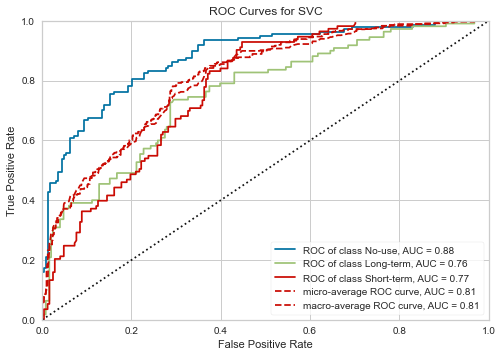

<AxesSubplot:title={'center':'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [15]:
visualizer.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()        

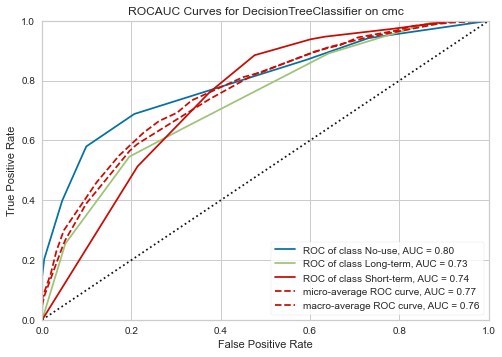

<AxesSubplot:title={'center':'ROCAUC Curves for DecisionTreeClassifier on cmc'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [16]:
visualizer_1.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer_1.score(X_test, y_test)        # Evaluate the model on the test data
visualizer_1.show()        

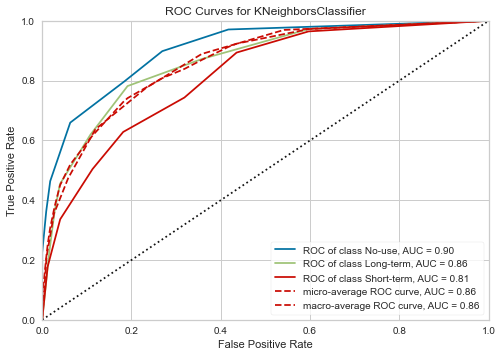

<AxesSubplot:title={'center':'ROC Curves for KNeighborsClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [17]:
visualizer_2.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer_2.score(X_test, y_test)        # Evaluate the model on the test data
visualizer_2.show()    